In [1]:
import os
import re
import glob
import matplotlib.pyplot as plt
import numpy as np
import cv2
import h5py
from pathlib import Path
from datetime import datetime

from PIL import Image as PILImage
import matplotlib.patches as patches

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor
from MirrorFeatureExtractor.mirror_feature_extractor import MirrorFeatureExtractor

In [2]:
def mark_mirrors_on_img(img_path, points_list):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)

    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor='red',
                facecolor='red',
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

def get_feature_matrix_from_img(img_path):
    mirror_extractor = SimpleMirrorExtractor(str(MIRROR_POINTS_JSON))
    mirror_feature_extractor = MirrorFeatureExtractor()
    new_feature_matrix = np.zeros((249, 11))
    img_gray = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2GRAY)
    for mirror_id in range(0, 249):
        mirror_crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=mirror_id)
        feat_texture = mirror_feature_extractor.extract_texture_features(mirror_crop)
        feat_edge_gradient = mirror_feature_extractor.extract_edge_and_gradient_features(mirror_crop)
        new_feature_matrix[mirror_id, :6] = list(feat_texture.values())
        new_feature_matrix[mirror_id, 6:] = list(feat_edge_gradient.values())
    return new_feature_matrix

def get_hour(path):
    match = re.search(r'(\d{8})_(\d{6})M', path)
    if match:
        time_str = match.group(2)  # "152000"
        return int(time_str[:2])   # 15
    return None

In [3]:
MY_COMP_OUTPUT_DIR_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis"
my_comp_root = Path("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2025/10/")

BASE_DIR = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data"
ROOT = Path(BASE_DIR) / "data/images_for_analysis"
MIRROR_POINTS_JSON = Path(BASE_DIR) / "points_IRCam.json"

In [4]:
image_paths = sorted(glob.glob("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/*.jpg"))
morning_img_paths = [p for p in image_paths if 7 <= get_hour(p) < 10]
n_images = len(morning_img_paths)
print(n_images)

mirror_extractor = SimpleMirrorExtractor(str(MIRROR_POINTS_JSON))
mirror_feature_extractor = MirrorFeatureExtractor()

feature_names = ['lbp_entropy', 'glcm_contrast', 'glcm_dissimilarity',
                 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
                 "sobel_mean", "soble_max",
                 "laplacian_mean", "laplacian_std", "edge_density"]

feature_matrix = np.zeros((n_images, 249, 11))  # wypełniasz w pętli po lustrach

for i, path in enumerate(morning_img_paths):
    img_gray = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2GRAY)
    for mirror_id in range(0, 249):
        mirror_crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=mirror_id)
        feat_texture = mirror_feature_extractor.extract_texture_features(mirror_crop)
        feat_edge_gradient = mirror_feature_extractor.extract_edge_and_gradient_features(mirror_crop)
        feature_matrix[i, mirror_id, :6] = list(feat_texture.values())
        feature_matrix[i, mirror_id, 6:] = list(feat_edge_gradient.values())

141


In [5]:
np.corrcoef(feature_matrix[:, 120, :])

array([[1.        , 0.99997622, 0.99997742, ..., 0.99964926, 0.99963478,
        0.99594624],
       [0.99997622, 1.        , 0.99999965, ..., 0.99978185, 0.99977036,
        0.99648897],
       [0.99997742, 0.99999965, 1.        , ..., 0.99976823, 0.99975635,
        0.99644751],
       ...,
       [0.99964926, 0.99978185, 0.99976823, ..., 1.        , 0.99999984,
        0.99795712],
       [0.99963478, 0.99977036, 0.99975635, ..., 0.99999984, 1.        ,
        0.99798949],
       [0.99594624, 0.99648897, 0.99644751, ..., 0.99795712, 0.99798949,
        1.        ]])

In [ ]:
mirror_id_list = [m_id for m_id in range(0, 240, 40)]
plt.figure()
for m_id in mirror_id_list:
    plt.plot(feature_matrix[:120, m_id, 5], label=m_id)
    plt.legend()
plt.show()

In [ ]:
plt.plot(feature_matrix[:, 17, 9], feature_matrix[:, 17, 0], 'bo')

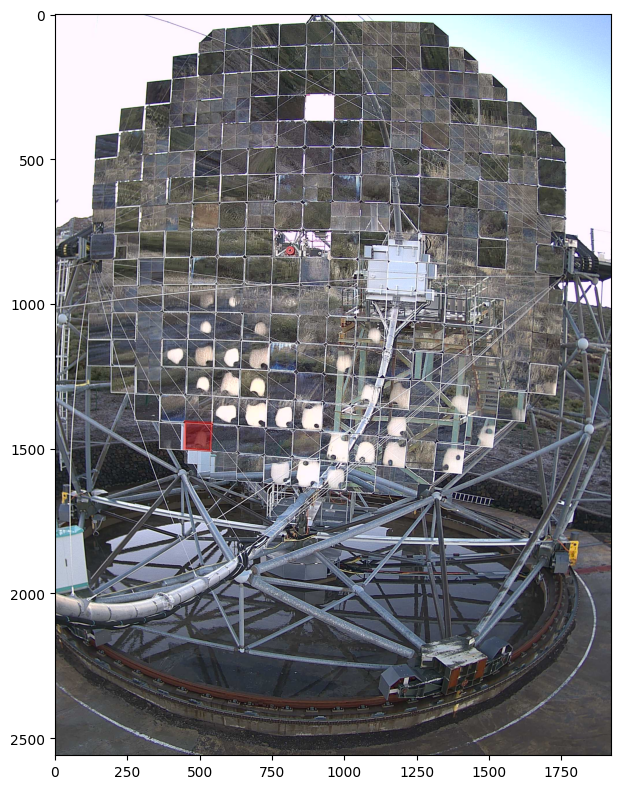

In [62]:
IMG_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/IRCamM1T20251005_075000M.jpg"
IMG_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2025/12/15/IRCamM1T20251215_081547M.jpg"
IMG_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2025/12/15/IRCamM1T20251215_081547M.jpg"
#IMG_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2025/12/15/IRCamM1T20251215_084547M.jpg"
#IMG_PATH = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2025/12/17/IRCamM1T20251217_081547M.jpg"

img_rgb = cv2.imread(str(IMG_PATH), cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(cv2.imread(str(IMG_PATH)), cv2.COLOR_BGR2GRAY)

mirror_extractor = SimpleMirrorExtractor(str(MIRROR_POINTS_JSON))

p_list = []
for m_id in [230]:
    p_list.append(mirror_extractor.get_point_coords(m_id))
mark_mirrors_on_img(IMG_PATH, p_list)

In [ ]:
feature_matrix.shape

In [ ]:
! ls ../data/

In [6]:
np.savez("../data/feature_matrix_2_morning.npz",
         feature_matrix=feature_matrix,
         feature_names=feature_names)

In [9]:
data = np.load("../data/feature_matrix_2_morning.npz", allow_pickle=True)

In [10]:
print(data["feature_matrix"].shape)
print(data["feature_names"].shape)

(141, 249, 11)
(11,)


In [11]:
f_matrix = data['feature_matrix'][:, :, :] # feature_matrix[:30, :, :] data['feature_matrix'][:120, :, :6]
baseline_median = np.median(f_matrix, axis=0)
baseline_mad = np.median(
    np.abs(f_matrix - baseline_median[np.newaxis, :, :]),
    axis=0
)*1.4826

#Minum MAD żeby uniknąć dzielenia przez 0
baseline_mad = np.maximum(baseline_mad, 1e-6) #

In [106]:
baseline_mad.shape

(249, 11)

In [63]:
new_feature_matrix = get_feature_matrix_from_img(IMG_PATH)
z_from_baseline = (new_feature_matrix - baseline_median) / baseline_mad

In [64]:
z_from_baseline.shape

(249, 11)

In [65]:
print(np.where(z_from_baseline[:, 8] > 3.))
print(np.where(z_from_baseline[:, 8] < -2.5))

(array([], dtype=int64),)
(array([  8, 189, 206, 219, 220, 221, 222, 235, 244]),)


In [117]:
z_from_baseline[207, 9]

np.float64(4.283625642856963)

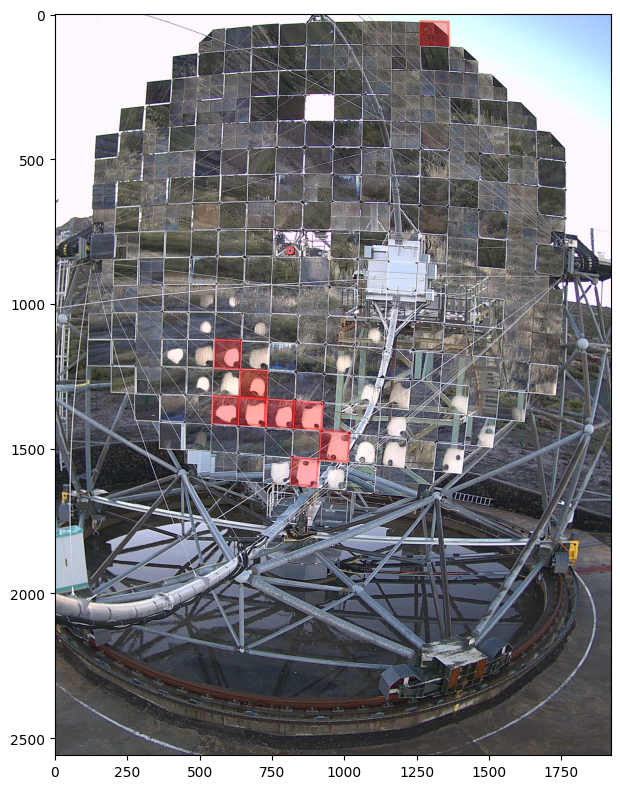

In [66]:
p_list = []
for m_id in [ 8, 189, 206, 219, 220, 221, 222, 235, 244]:
    p_list.append(mirror_extractor.get_point_coords(m_id))
mark_mirrors_on_img(IMG_PATH, p_list)

In [31]:
new_feature_matrix[17, 0]

np.float64(3.195196053073498)

In [24]:
feature_names = ['lbp_entropy', 'glcm_contrast', 'glcm_dissimilarity',
                 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
                 "sobel_mean", "soble_max",
                 "laplacian_mean", "laplacian_std", "edge_density"]

feat_names_dict = {}
i = 0
for name in feature_names:
    feat_names_dict[name] = i
    i += 1

print(feat_names_dict)

{'lbp_entropy': 0, 'glcm_contrast': 1, 'glcm_dissimilarity': 2, 'glcm_homogeneity': 3, 'glcm_energy': 4, 'glcm_correlation': 5, 'sobel_mean': 6, 'soble_max': 7, 'laplacian_mean': 8, 'laplacian_std': 9, 'edge_density': 10}


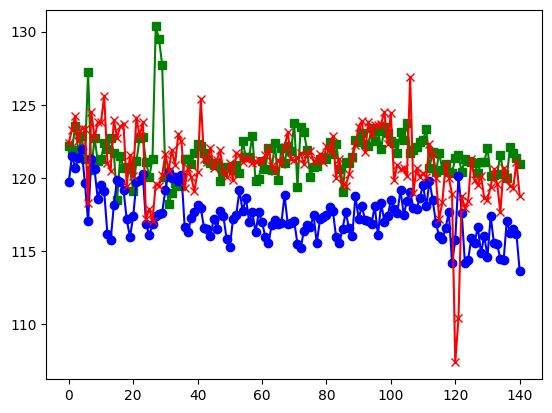

In [48]:
feat_id = feat_names_dict['laplacian_mean']
plt.plot(f_matrix[:, 70, feat_id], 'gs-')
plt.plot(f_matrix[:, 133, feat_id], 'bo-')
plt.plot(f_matrix[:, 150, feat_id], 'rx-')

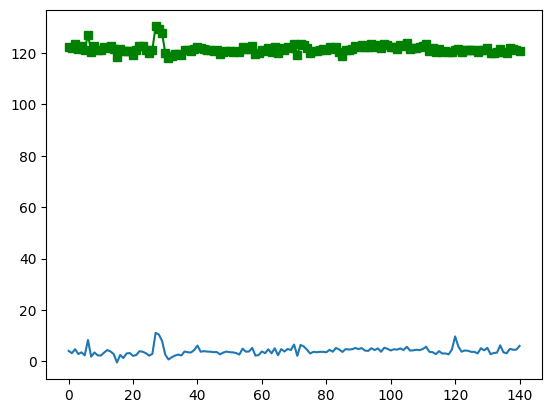

In [53]:
norm_feat = f_matrix[:, 70, feat_id] - f_matrix[:, :, feat_id].mean(axis=1)
plt.plot(f_matrix[:, 70, feat_id], 'gs-')
plt.plot(norm_feat)

In [44]:
f_matrix[:, 60, feat_id].std()

np.float64(127.2591076468229)

In [37]:
f_matrix[:, :, 2].shape

(141, 249)

In [39]:
f_matrix[:, :, 2].mean(axis=1).shape

(141,)

In [31]:
f_matrix[:, :, feat_id].mean(a)

np.float64(918.0046101026753)

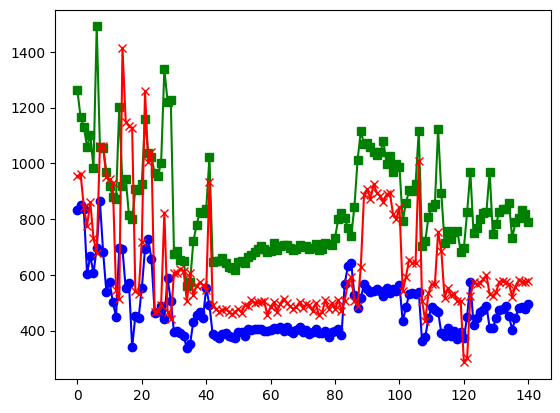

In [27]:
feat_id = feat_names_dict['glcm_contrast']
plt.plot(f_matrix[:, 70, feat_id], 'gs-')
plt.plot(f_matrix[:, 133, feat_id], 'bo-')
plt.plot(f_matrix[:, 150, feat_id], 'rx-')

(array([  1.,   0.,   0.,   0.,   0.,   0.,   7.,  48.,  91., 102.]),
 array([ 5.33984375,  5.83945313,  6.3390625 ,  6.83867188,  7.33828125,
         7.83789062,  8.3375    ,  8.83710938,  9.33671875,  9.83632813,
        10.3359375 ]),
 <BarContainer object of 10 artists>)

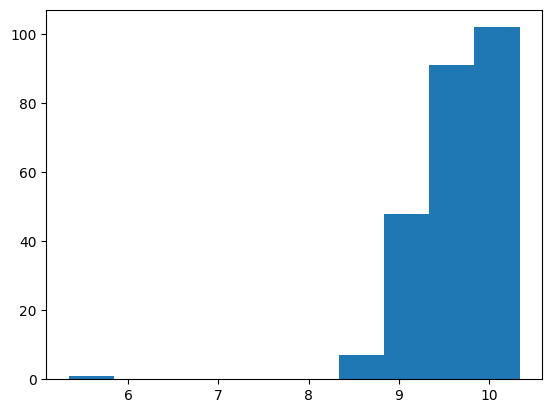

In [31]:
plt.hist(f_matrix[22, :, feat_id])